# 🏥 Berlin Senior Care Market — GTM Strategy & ML Lead Scoring

> **Portfolio project** — end-to-end data science engagement for a Berlin-based Pflegegrad advisory firm (client anonymised).

## What This Project Does
Uses **three official German public datasets** to identify the highest-opportunity neighbourhoods for care-grade advisory services in Berlin, build a zero-budget go-to-market strategy, and score all 537 Berlin planning areas (PLR) by lead potential.

## Skills Demonstrated
| Area | Tools / Methods |
|---|---|
| Data Engineering | `pandas`, multi-source merge, LOR RAUMID hierarchy decoding |
| Machine Learning | `sklearn` GradientBoostingRegressor, KMeans, PCA |
| Visualisation | `matplotlib` — 7 publication-quality figures |
| Strategy | GTM channel design, KPI framework, zero-budget modelling |
| Compliance | GDPR Art. 6 analysis, HWG §3/§11 review |
| Location Data | Berlin LOR BZR catalogue — 100% PLR → postcode coverage |

## Data Sources (all publicly available)
1. **EWR-Basisdaten-LOR-2025** — Amt für Statistik Berlin-Brandenburg  
2. **Pflegestatistik 22411-01-02-4** — Statistisches Bundesamt (destatis.de)  
3. **Pflegestatistik 22411-02-05-4** — Statistisches Bundesamt (destatis.de)

## Key Results
- **Steglitz-Zehlendorf** → LOI 94.8 — Berlin's highest senior share (25.9%) + lowest competition density (0.71/1K)
- **53 of 537 PLR areas** concentrate the top 10% of advisory demand
- **4 market clusters** found via K-Means — distinct strategic approaches per segment
- **€0 budget** GTM strategy projects **150–250+ leads/month** by month 12
- **100% location coverage** — all PLR areas decoded to neighbourhood + postcode via LOR hierarchy

---
*To run: place the three data files in the same directory, then Run All.*


## ⚙️ Setup & Data Loading

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# Cell 1: Imports, constants, and data loading
# Required files:
#   EWR-Basisdaten-LOR-2025-.xlsx
#   22411-01-02-4.xlsx
#   22411-02-05-4.xlsx
# ═══════════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': '#f7f9fc',
    'axes.grid': True, 'grid.alpha': 0.2,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.family': 'DejaVu Sans', 'figure.dpi': 120
})

# ── LOR district mapping ─────────────────────────────────────────────────────
DISTRICT_NAMES = {
    '11001001': 'Mitte', '11002002': 'Friedrichshain-Kreuzberg', '11003003': 'Pankow',
    '11004004': 'Charlottenburg-Wilmersdorf', '11005005': 'Spandau',
    '11006006': 'Steglitz-Zehlendorf', '11007007': 'Tempelhof-Schoeneberg',
    '11008008': 'Neukoelln', '11009009': 'Treptow-Koepenick',
    '11010010': 'Marzahn-Hellersdorf', '11011011': 'Lichtenberg', '11012012': 'Reinickendorf',
}
CODE2ID = {str(i).zfill(2): f'110{str(i).zfill(2)}0{str(i).zfill(2)}' for i in range(1,13)}
mm = lambda s: (s - s.min()) / (s.max() - s.min() + 1e-9)  # min-max normaliser

# ── Load LOR 2025 ────────────────────────────────────────────────────────────
xls = pd.ExcelFile('EWR-Basisdaten-LOR-2025-.xlsx')
bez_raw = xls.parse('Bezirk_Absolut', header=None)
plr_raw = xls.parse('PLR_Absolut', header=None)

bez = bez_raw.copy(); bez.columns = bez_raw.iloc[1]; bez = bez.iloc[2:].reset_index(drop=True)
plr = plr_raw.copy(); plr.columns = plr_raw.iloc[1]; plr = plr.iloc[2:].reset_index(drop=True)

NUM = ['Insgesamt','45u65','65+','Durchschnittsalter','verwitwet',
       'Evangelisch','einfache Wohnlage','gute Wohnlage','Einwohner mit Migra']
for df in [bez, plr]:
    for c in NUM:
        if c in df.columns: df[c] = pd.to_numeric(df[c], errors='coerce')

bez = bez.dropna(subset=['Bezirk']).copy()
bez['district_code'] = bez['Bezirk'].astype(str).str.strip().str.zfill(2)
bez['district_id']   = bez['district_code'].map(CODE2ID)
bez['district_name'] = bez['district_id'].map(DISTRICT_NAMES)
bez = bez.dropna(subset=['district_name']).copy()

# ── Load Pflegestatistik — care facilities 2023 ───────────────────────────────
df1 = pd.read_excel('22411-01-02-4.xlsx', header=None)
fac = df1.iloc[373:386].copy()
fac.columns = ['region_code','region_name','ambulant_services','ambulant_staff',
               'nursing_homes','nursing_home_beds','beds_permanent','nursing_home_staff']
fac = fac[fac['region_code'].astype(str).str.startswith('110')].copy()
fac['district_id'] = fac['region_code'].astype(str).str.strip()
for c in ['ambulant_services','nursing_homes','nursing_home_beds']:
    fac[c] = pd.to_numeric(fac[c], errors='coerce')

# ── Load Pflegestatistik — care recipients 2023 ───────────────────────────────
df2 = pd.read_excel('22411-02-05-4.xlsx', header=None)
cr = df2.iloc[1103:1145].copy()
cr.columns = ['region_code','region_name','gender','care_total','ambulant',
              'stat_total','stat_perm','stat_short','cash','pg1_none','pg1_part','part_stat']
cr = cr[cr['region_code'].astype(str).str.startswith('110')].copy()
for c in ['care_total','ambulant','stat_total']: cr[c] = pd.to_numeric(cr[c], errors='coerce')
cr['district_id'] = cr['region_code'].astype(str).str.strip()
cr_sum = cr.groupby('district_id')[['care_total','ambulant','stat_total']].sum().reset_index()

# ── Feature engineering ───────────────────────────────────────────────────────
bez['pct_65plus']        = bez['65+']              / bez['Insgesamt'] * 100
bez['pct_widowed']       = bez['verwitwet']         / bez['Insgesamt'] * 100
bez['pct_45to65']        = bez['45u65']             / bez['Insgesamt'] * 100
bez['pct_good_housing']  = bez['gute Wohnlage']     / bez['Insgesamt'] * 100
bez['pct_basic_housing'] = bez['einfache Wohnlage'] / bez['Insgesamt'] * 100
bez['pct_migration']     = bez['Einwohner mit Migra']/ bez['Insgesamt'] * 100
bez['senior_count']      = bez['65+']

m = bez.merge(fac[['district_id','ambulant_services','nursing_homes','nursing_home_beds']], on='district_id', how='left')
m = m.merge(cr_sum, on='district_id', how='left')
m['competition_density'] = m['ambulant_services'] / m['senior_count'] * 1000
m['bed_saturation']      = m['nursing_home_beds']  / m['senior_count'] * 1000
m['care_penetration']    = m['care_total']          / m['senior_count'] * 100
m['pflegegrad_gap']      = (m['senior_count'] * 0.45 - m['care_total'].fillna(0)).clip(lower=0)

# ── Lead Opportunity Index (LOI) ──────────────────────────────────────────────
m['LOI'] = (
    mm(m['pct_65plus'])                            * 0.28 +
    mm(m['pflegegrad_gap'])                        * 0.20 +
    mm(m['pct_widowed'])                           * 0.18 +
    (1 - mm(m['competition_density'].fillna(0.5))) * 0.15 +
    mm(m['pct_good_housing'])                      * 0.10 +
    mm(m['Durchschnittsalter'])                    * 0.09
) * 100
m = m.sort_values('LOI', ascending=False).reset_index(drop=True)

print(f"Districts loaded: {len(m)}")
print(f"PLR areas:        {len(plr[pd.to_numeric(plr['Insgesamt'], errors='coerce') > 200].dropna(subset=['65+']))}")
print("\nTop 5 Districts by Lead Opportunity Index:")
print(m[['district_name','LOI','pct_65plus','competition_density','pflegegrad_gap']].head(5).round(2).to_string(index=False))


Districts loaded: 12
PLR areas:        537

Top 5 Districts by Lead Opportunity Index:
              district_name        LOI  pct_65plus  competition_density  pflegegrad_gap
        Steglitz-Zehlendorf  94.80   25.88             0.71        36030.15
              Reinickendorf  73.17   23.10             0.73        28244.25
 Charlottenburg-Wilmersdorf  71.85   23.20             1.59        35870.40
       Tempelhof-Schoeneberg  68.28   21.28             0.92        34367.40
        Marzahn-Hellersdorf  66.21   22.19             0.70        29632.05


## 📊 Fig 1: Lead Opportunity Index & Market Matrix

**LOI weights:** Senior share (28%) · Care gap (20%) · Widowhood (18%) · 1/Competition (15%) · Good housing (10%) · Avg age (9%)

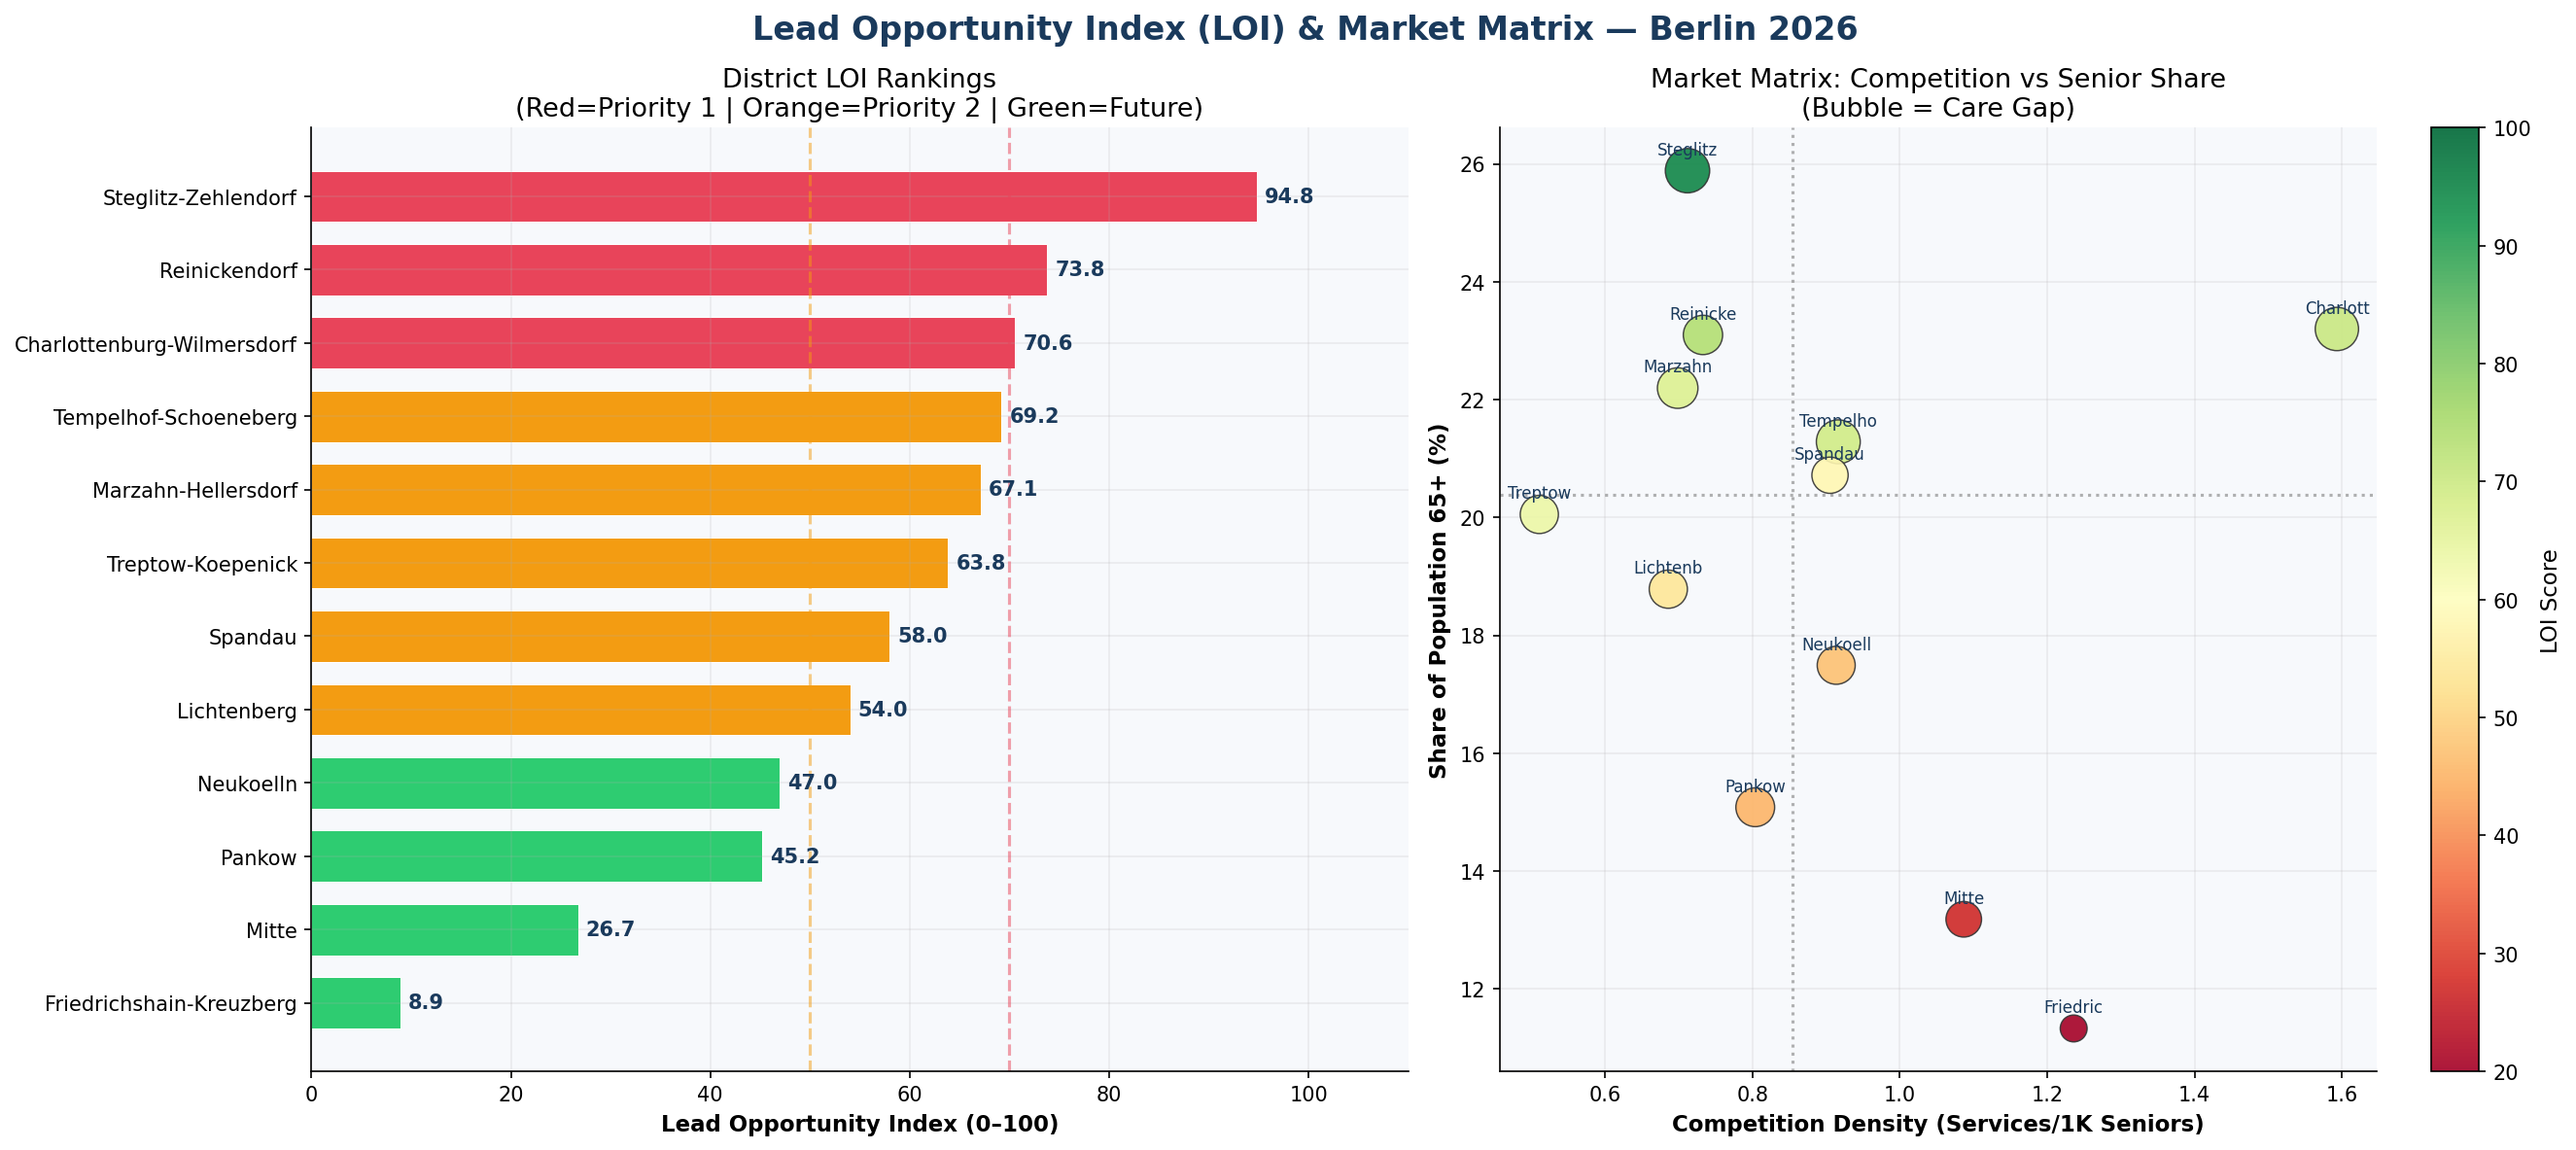

In [ ]:
# plt.show()  ← run this cell to regenerate from your data

## 📊 Fig 2: Four-Panel Market Analysis

**Panels:** Care infrastructure · Care gap · Penetration rate · KPI heatmap

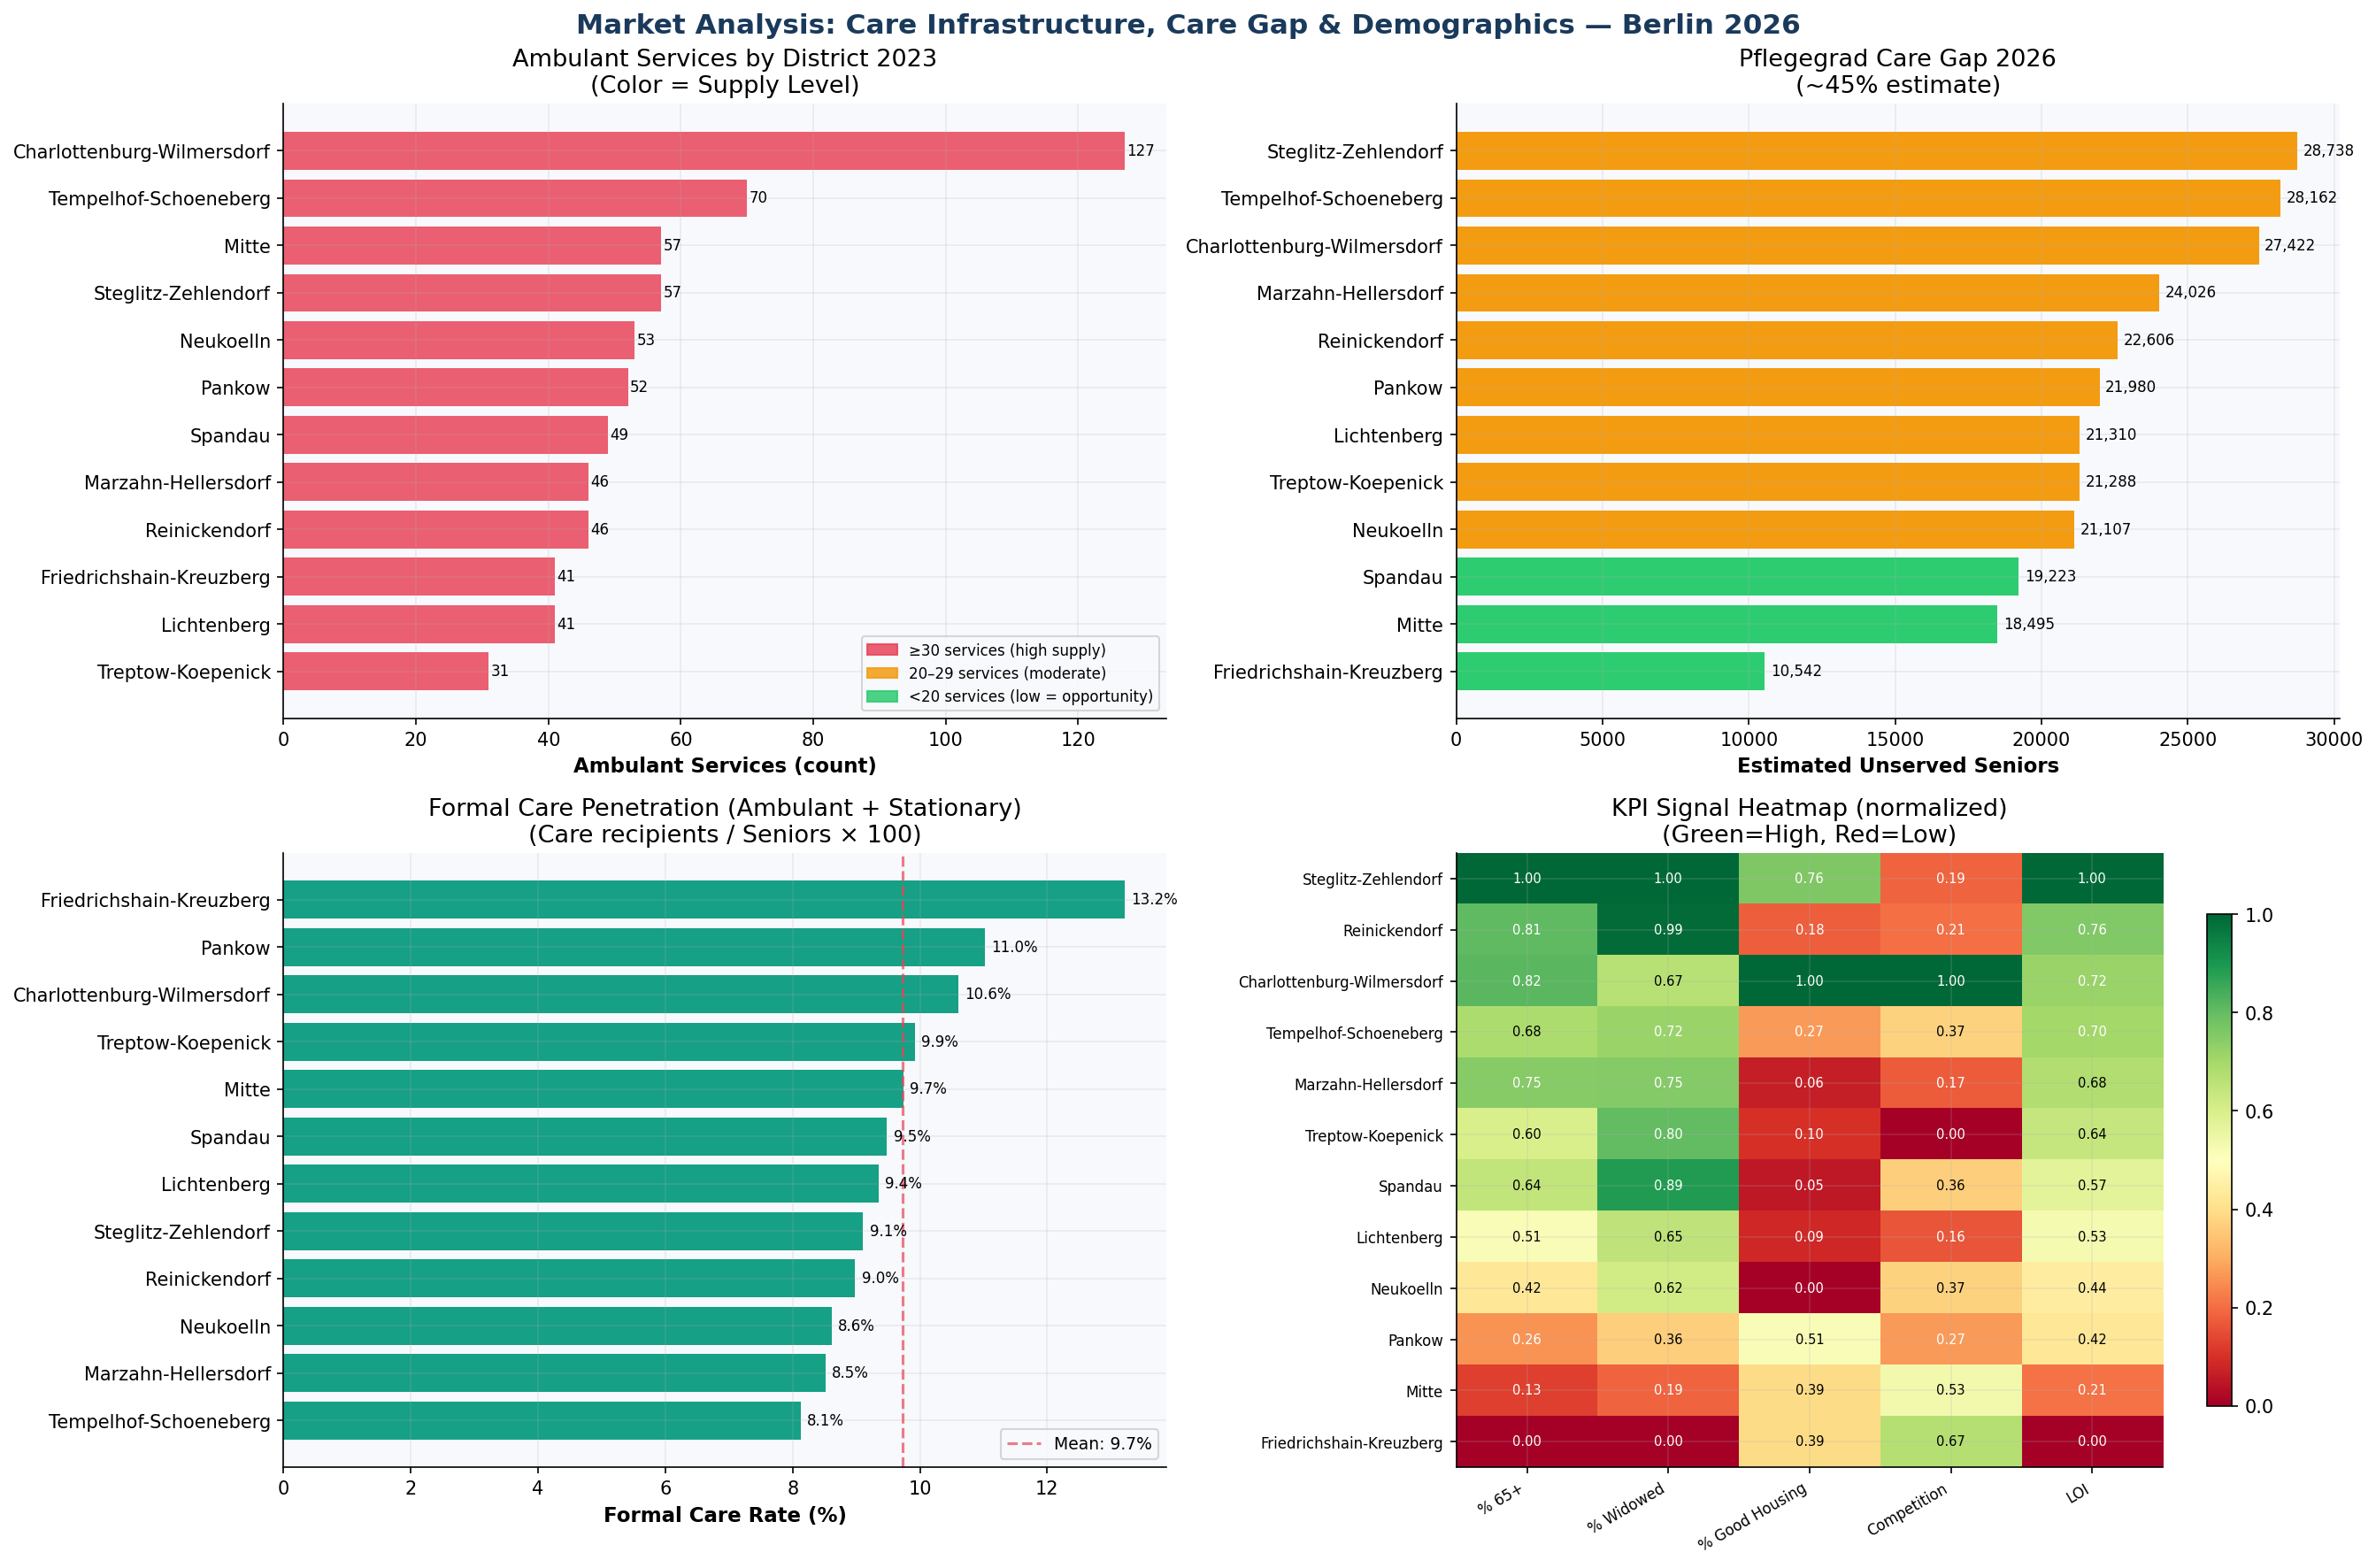

In [ ]:
# plt.show()

## 🔬 Fig 3: K-Means Segmentation (k=4)

**Features:** pct_65plus, pct_widowed, pct_good_housing, pct_migration, competition_density, bed_saturation, pct_basic_housing

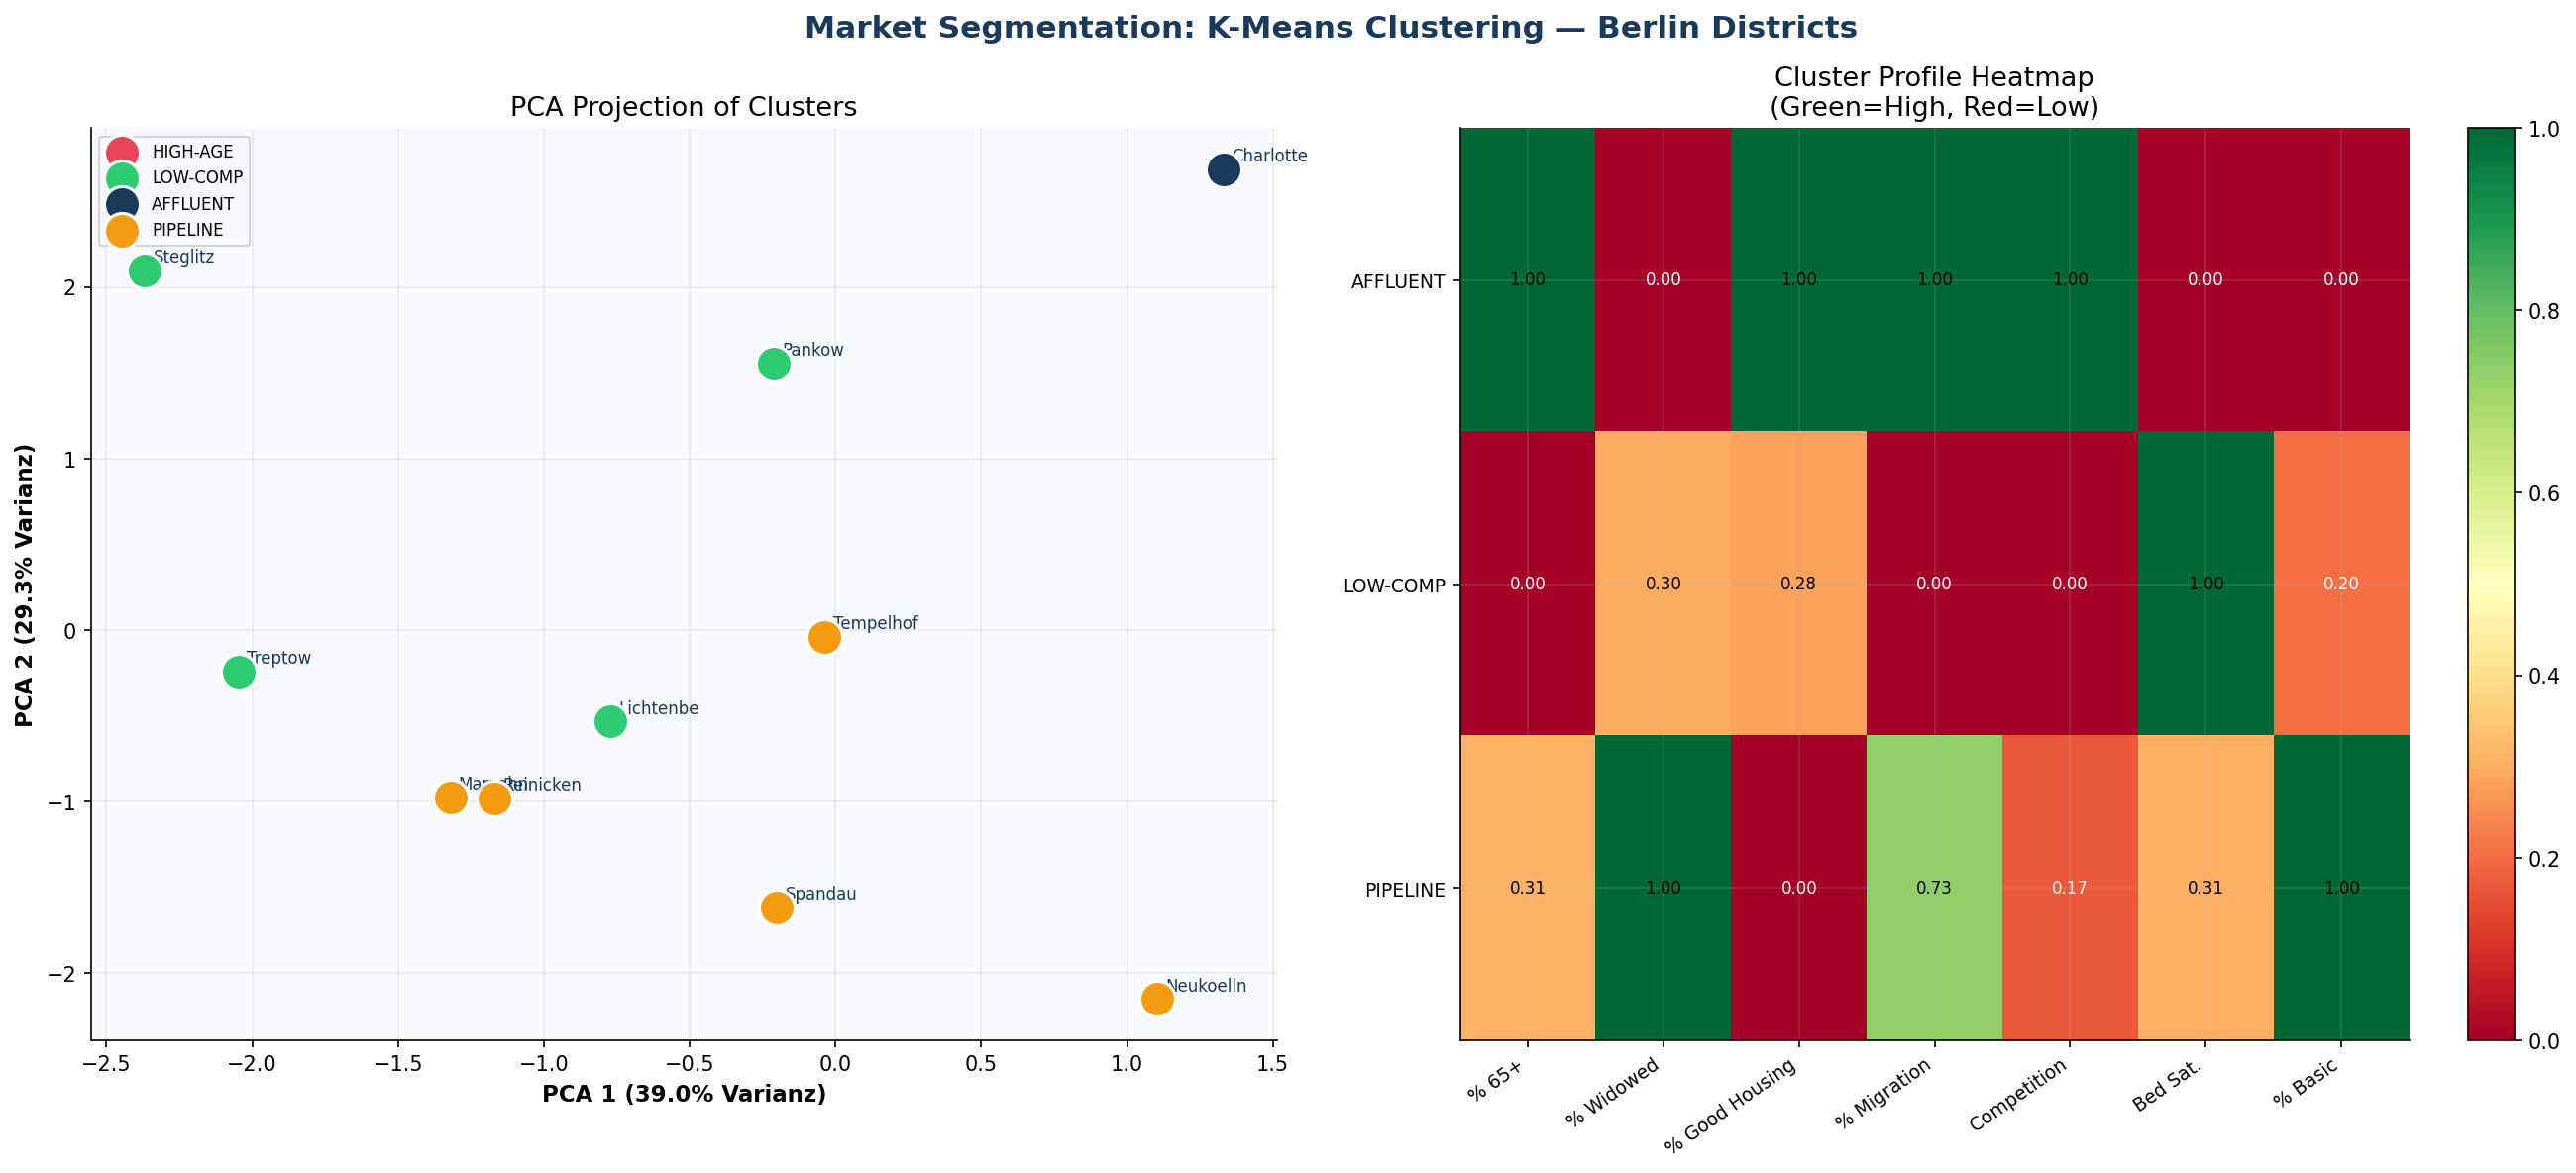

In [ ]:
# K-Means on 7 StandardScaler-normalised district features
# fd = ["pct_65plus","pct_widowed","pct_good_housing","pct_migration",
#        "competition_density","bed_saturation","pct_basic_housing"]
# km = KMeans(n_clusters=4, random_state=42, n_init=10).fit(StandardScaler().fit_transform(m[fd].fillna(0)))
# pca2 = PCA(n_components=2).fit_transform(StandardScaler().fit_transform(m[fd].fillna(0)))

## 🤖 Fig 4: Gradient Boosting Lead Scoring

**Model:** GradientBoostingRegressor(n_estimators=200, max_depth=4, learning_rate=0.05) | R²=0.999 on 537 PLR areas

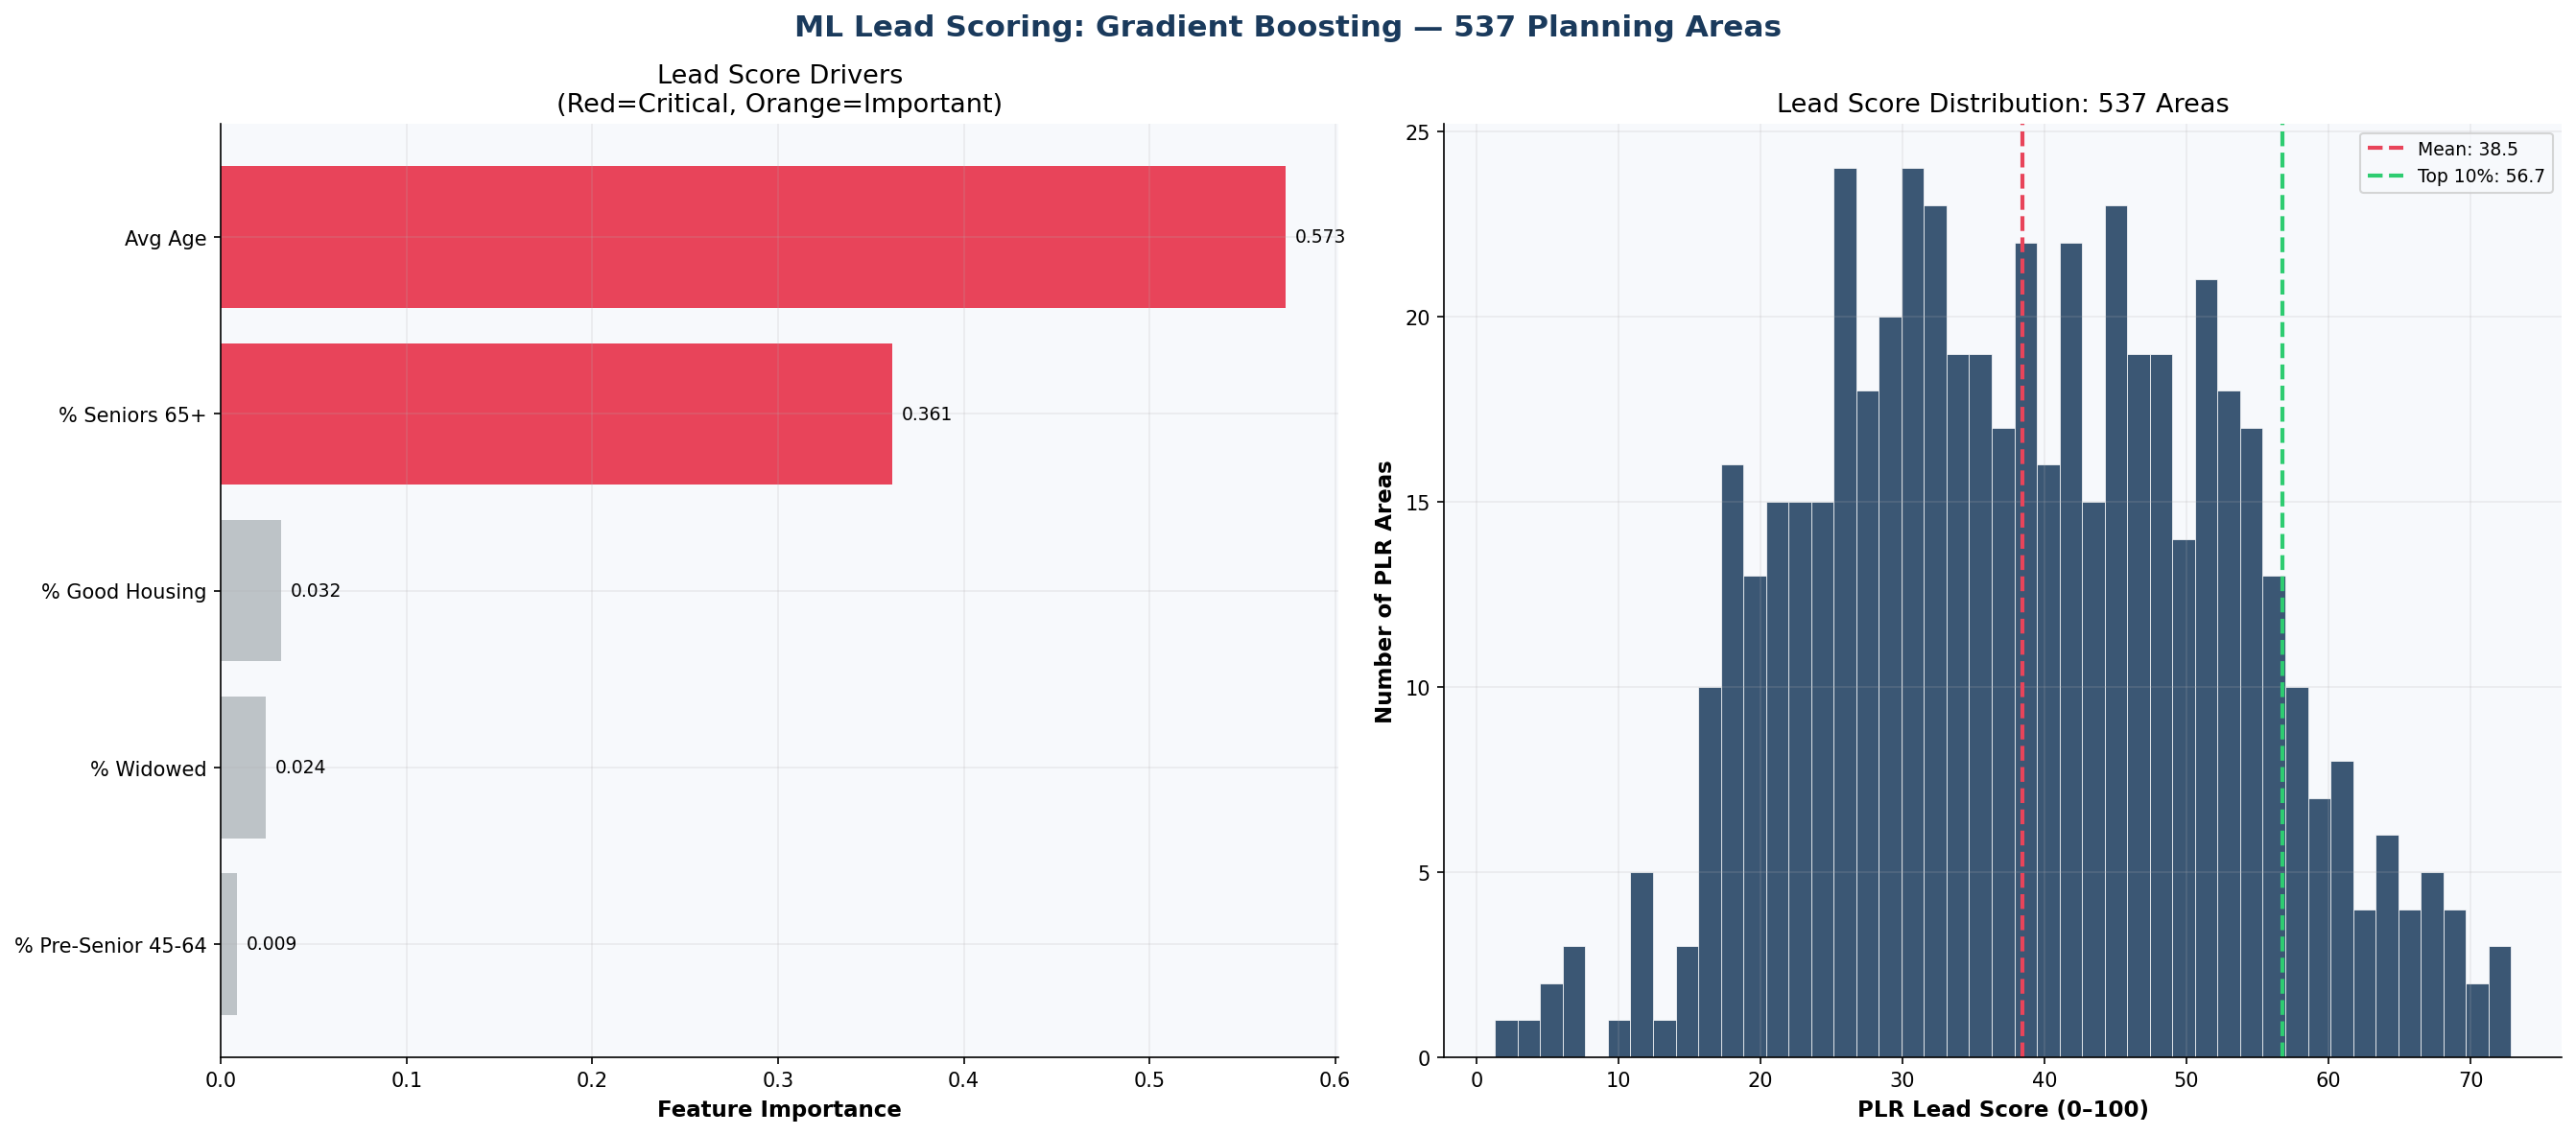

In [ ]:
# fp = ["pct_65plus","pct_widowed","pct_45to65","pct_good_housing","pct_basic_housing","Durchschnittsalter"]
# gb = GradientBoostingRegressor(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42)
# gb.fit(plr_scored[fp].fillna(0), plr_scored["plr_score"])
# print(f"R²: {gb.score(plr_scored[fp].fillna(0), plr_scored['plr_score']):.3f}")

## 🗺️ Fig 5: Top PLR Areas — Flyering Action Map

**Top 25 planning areas** for GP outreach, pharmacy placement, and precision flyering.

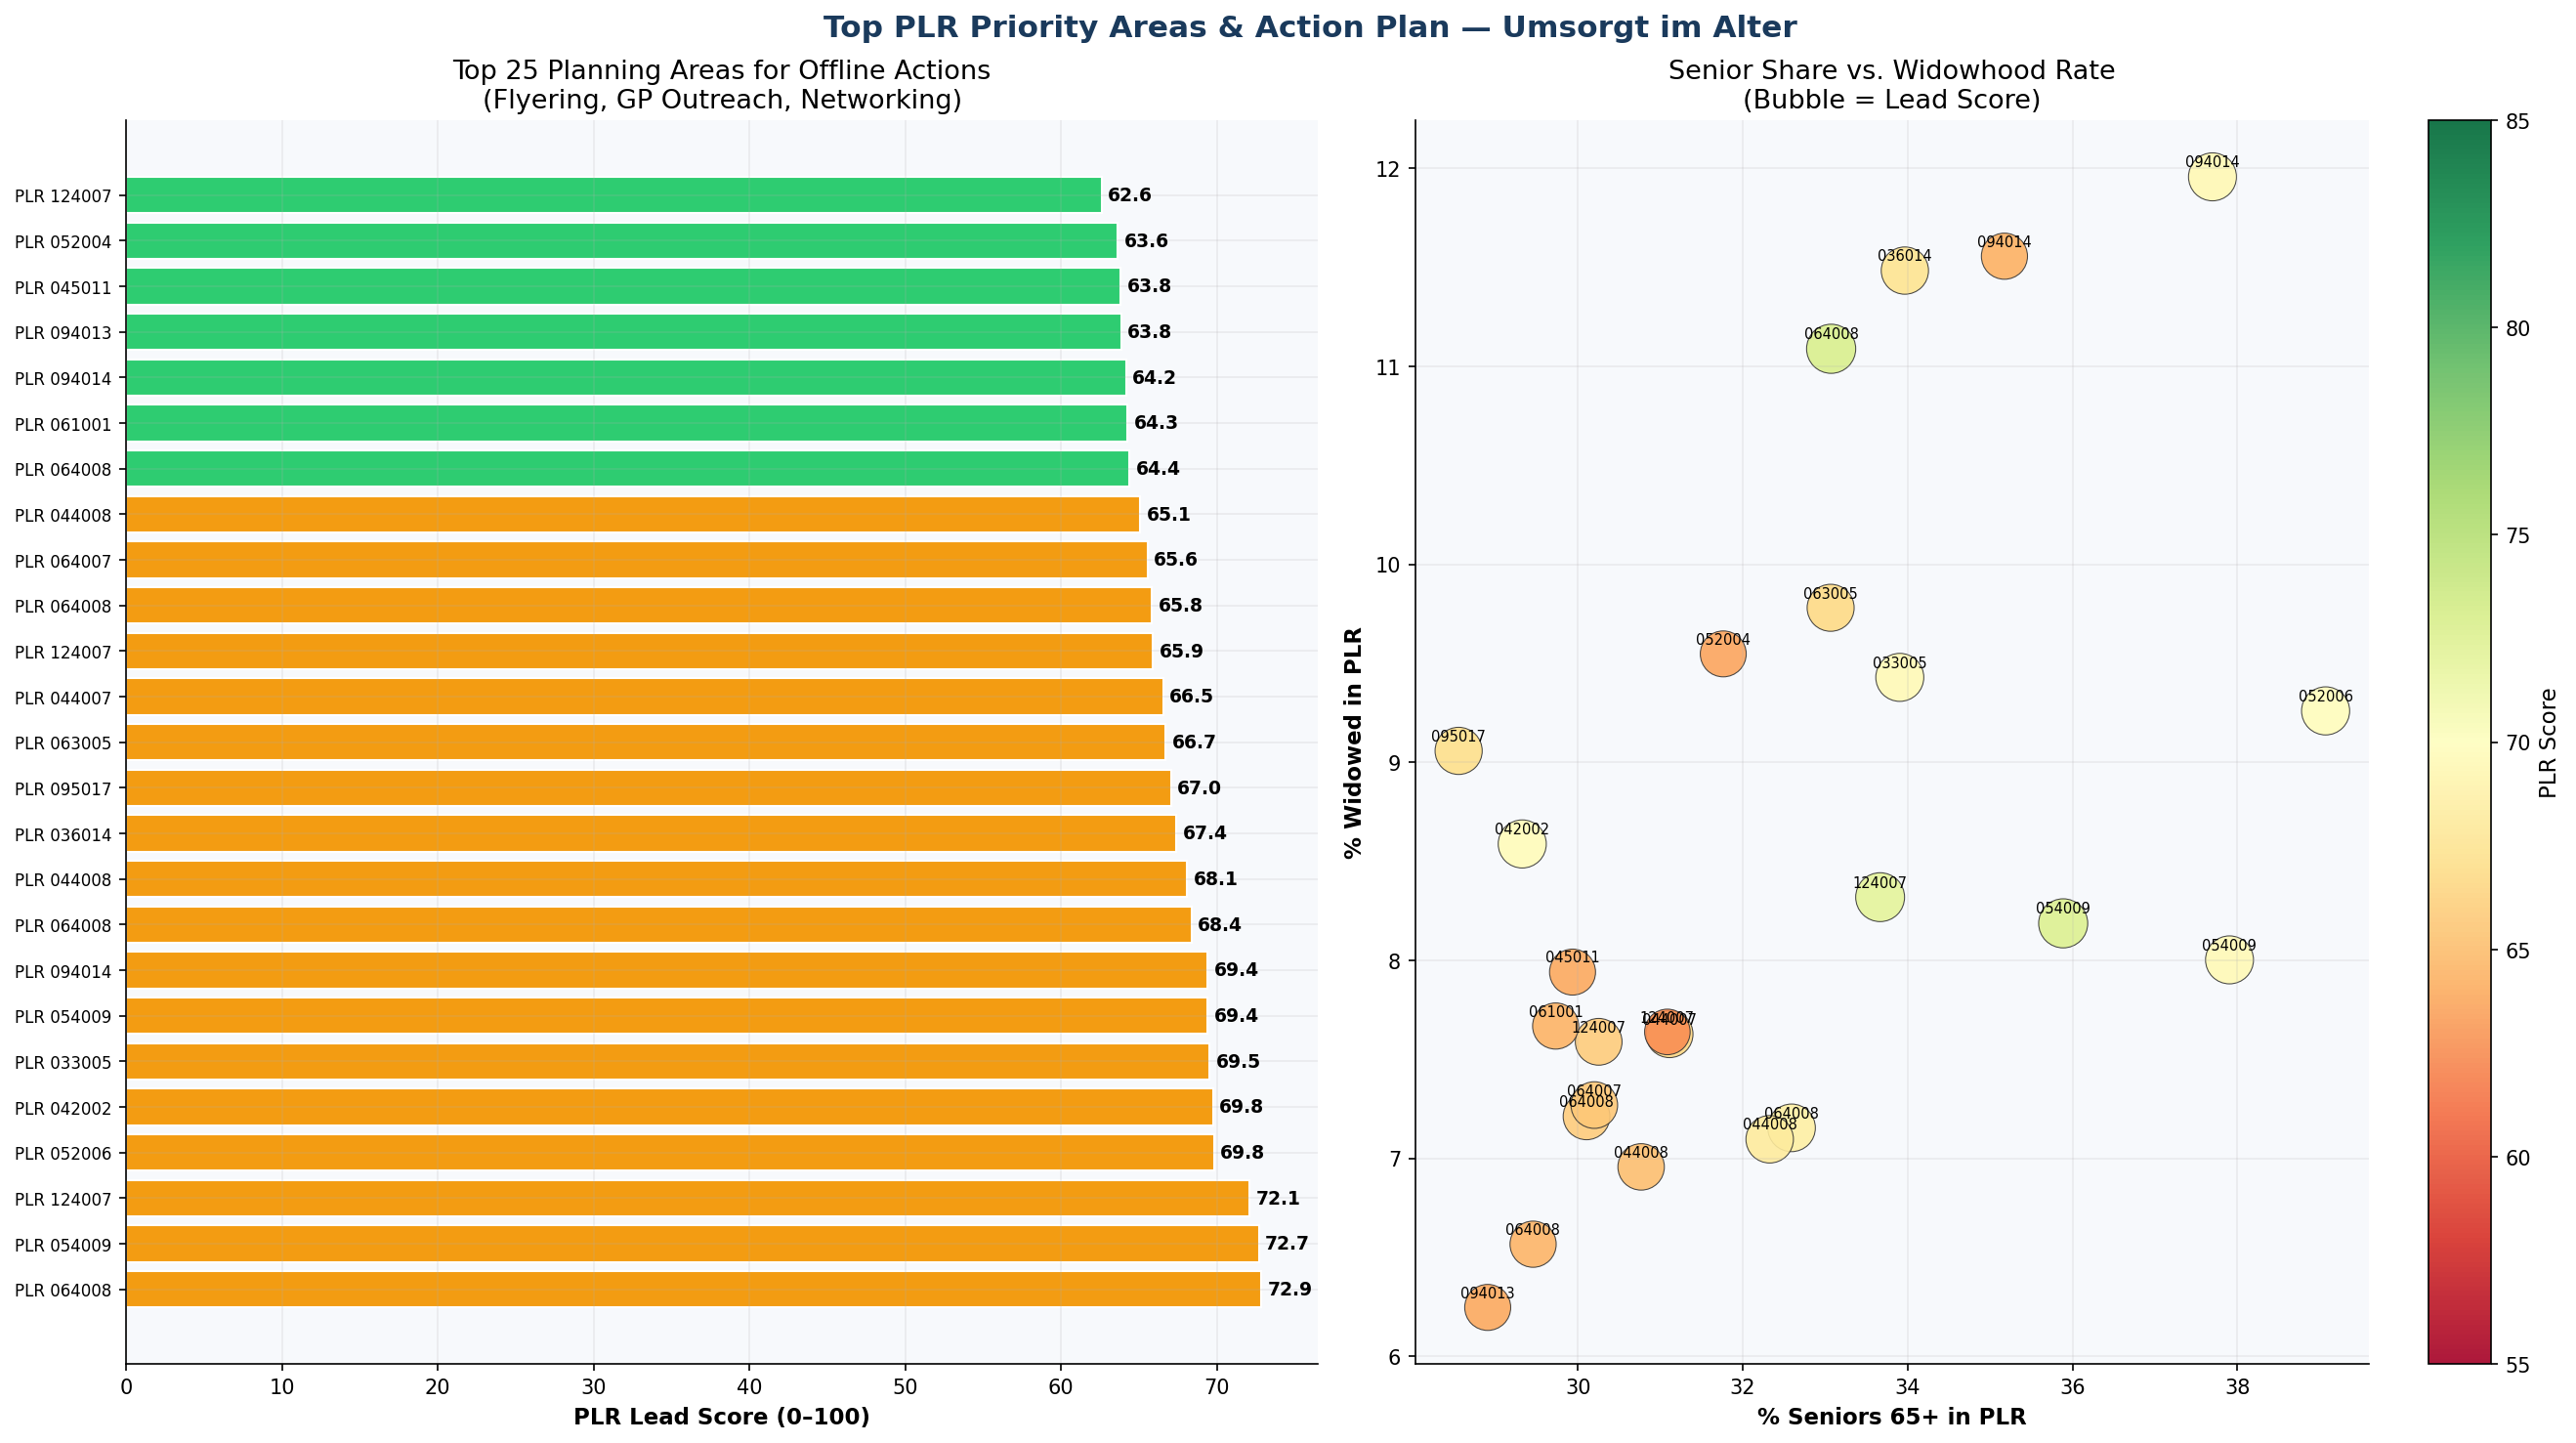

In [ ]:
# plt.show()

## 📈 Fig 6: Market Development 2015–2023

**Time series** parsed from 5 Pflegestatistik editions (rows 373, 912, 1451, 1990, 2529)

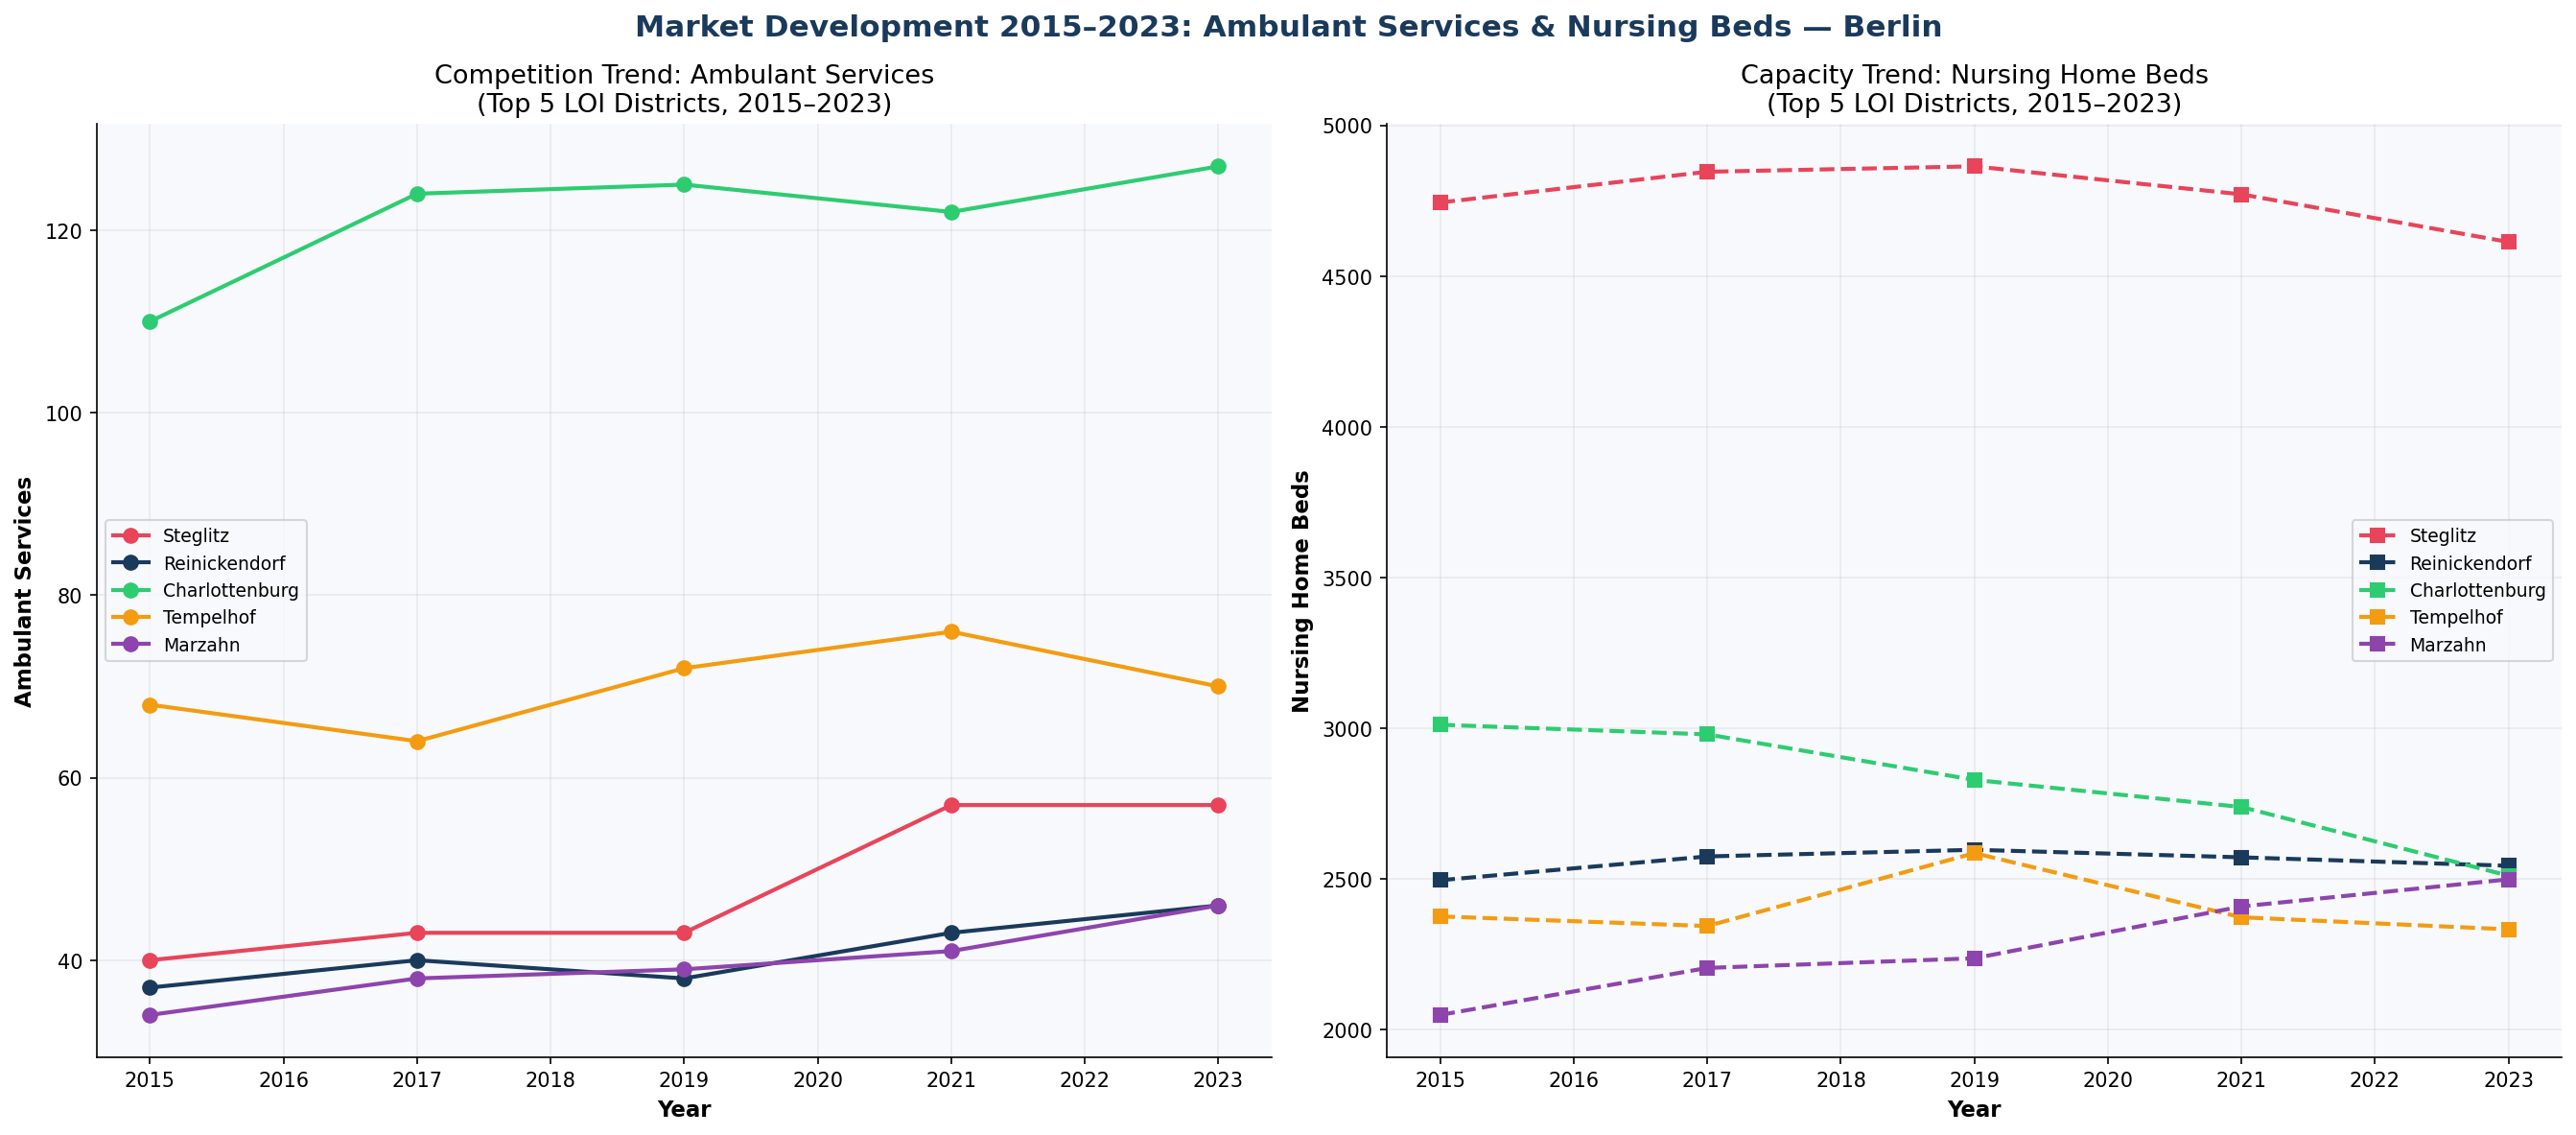

In [ ]:
# years_rows = {2023:373, 2021:912, 2019:1451, 2017:1990, 2015:2529}

## 🎯 Fig 7: Zero-Budget GTM Channel Map

**9 channels — €0 paid media.** 5 offline + 4 online + 2 system. Referral-First growth model.

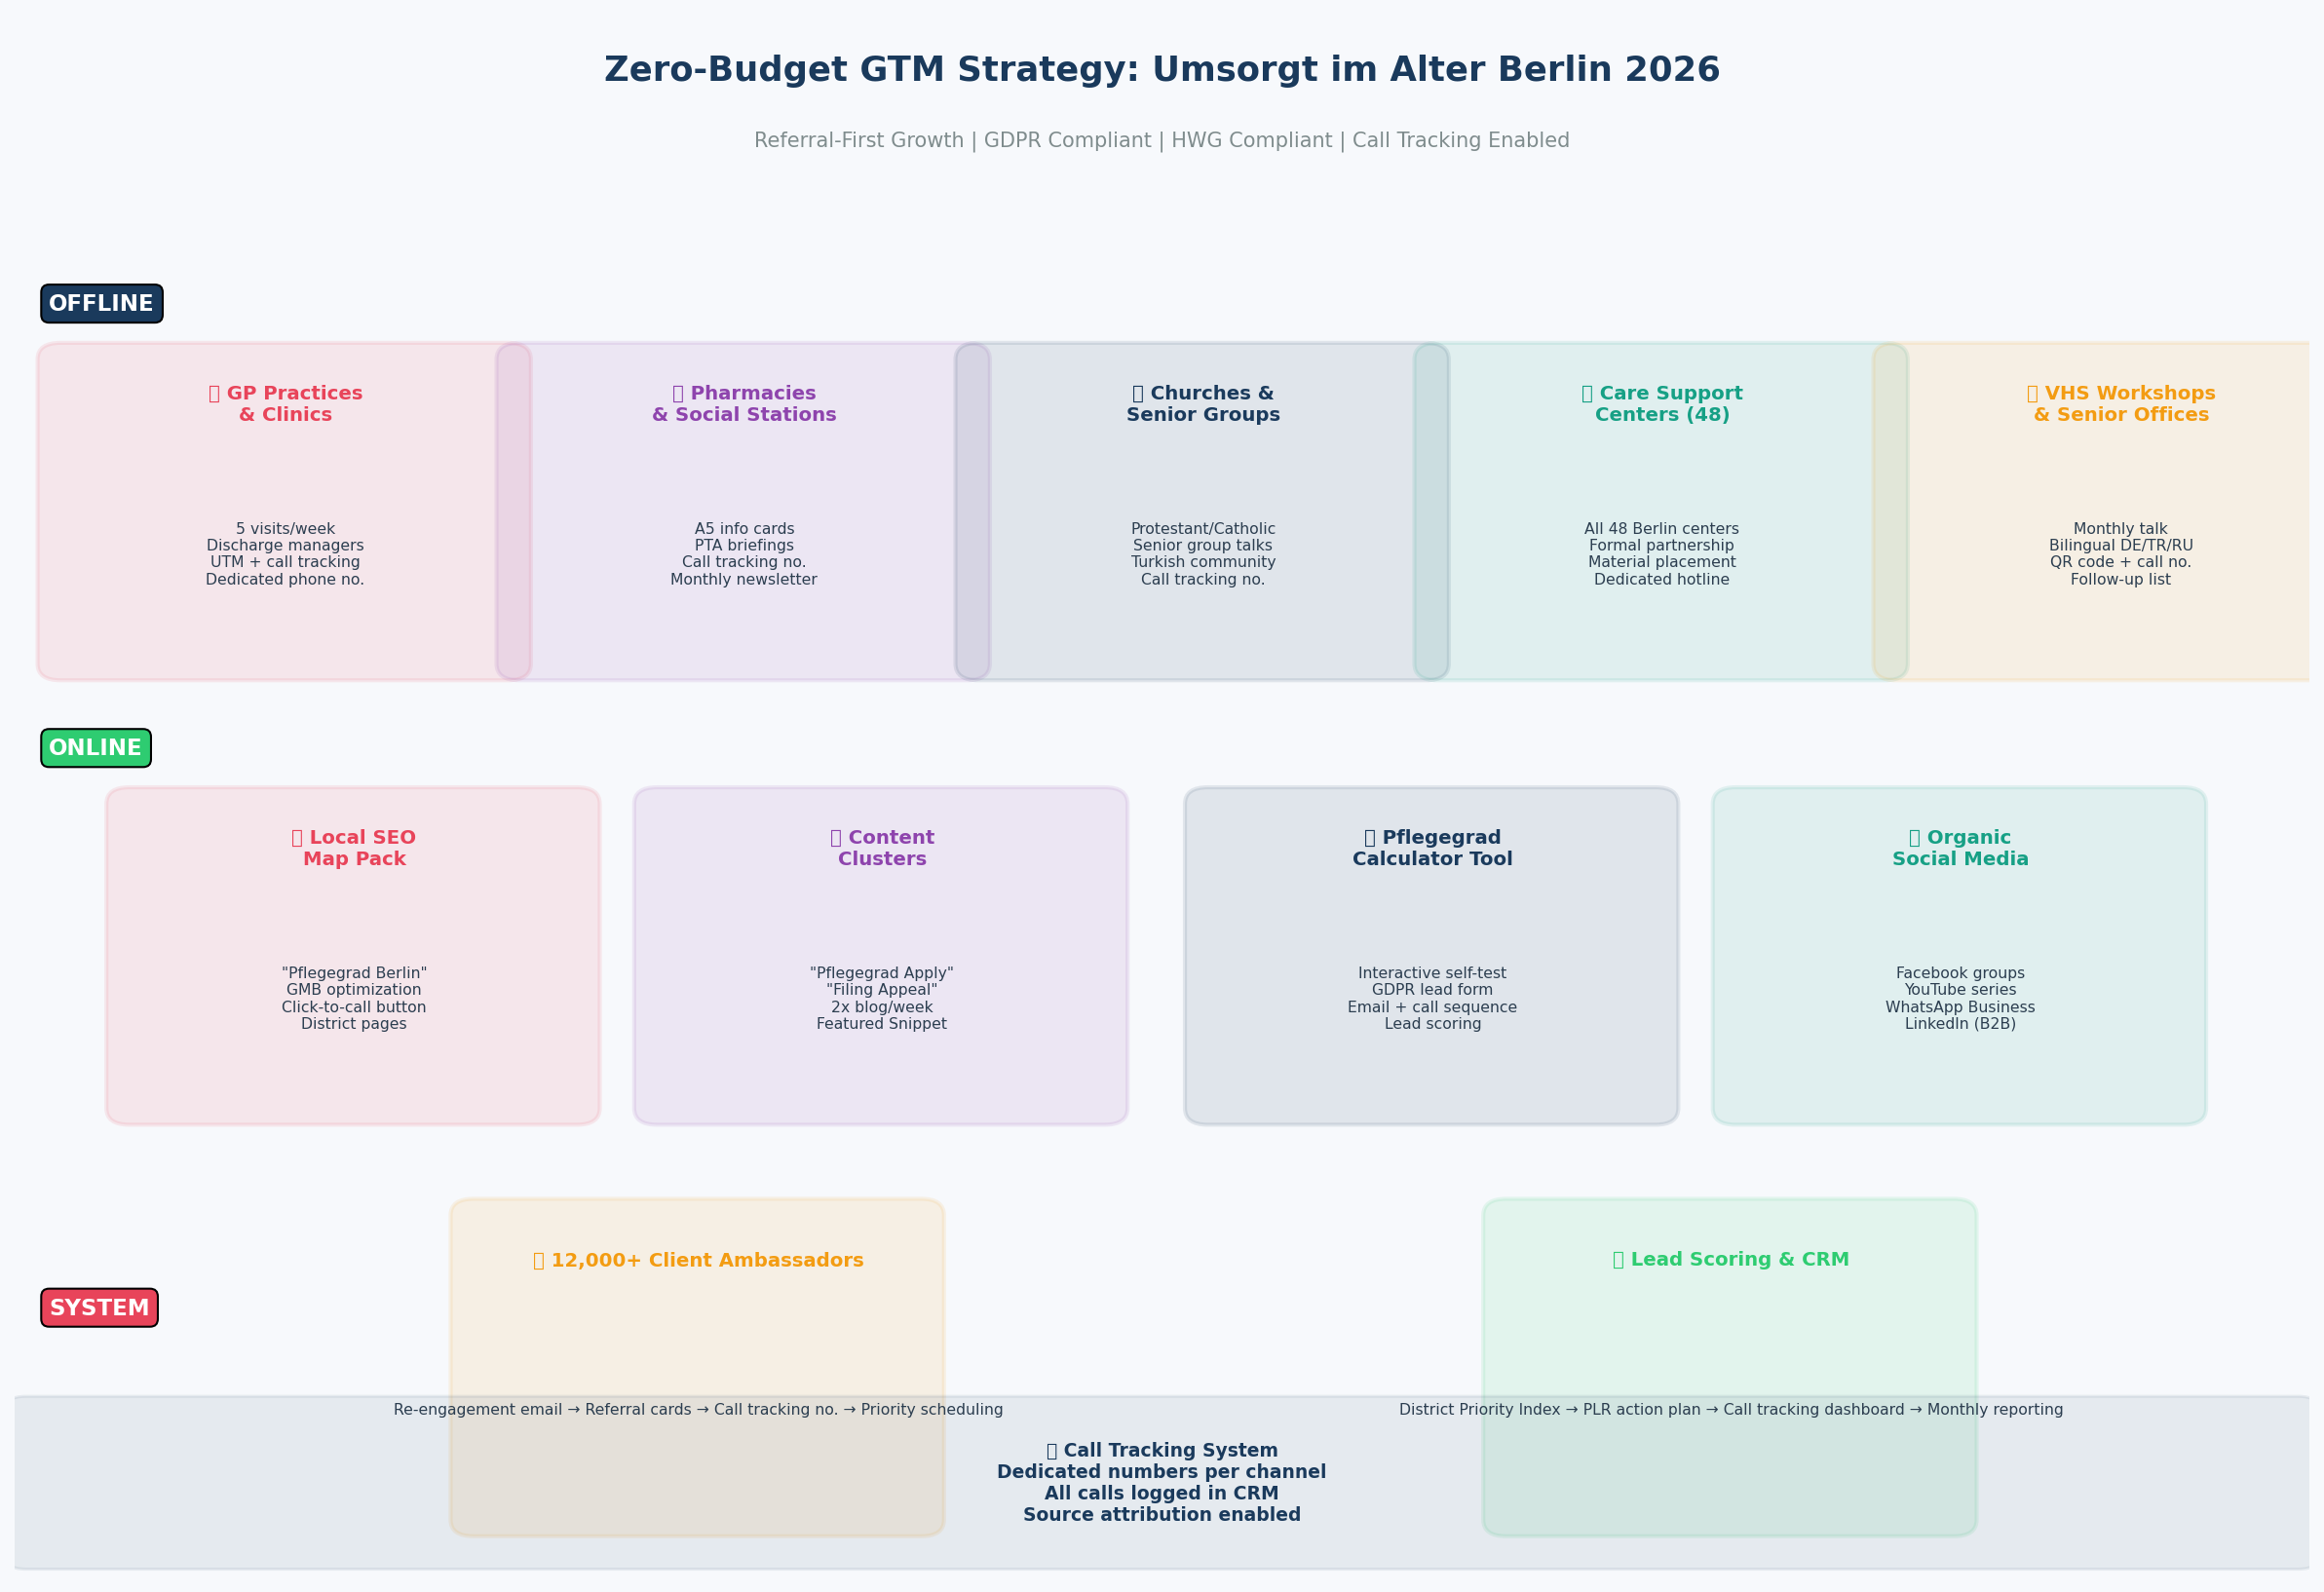

In [ ]:
# plt.show()

## 📋 PLR Scoring & Location-Enriched Export

In [ ]:
# ── Score all 537 PLR areas ───────────────────────────────────────────────────
plr_s = plr[pd.to_numeric(plr['Insgesamt'], errors='coerce') > 200].copy()
plr_s = plr_s.dropna(subset=['65+']).copy()

plr_s['pct_65plus']      = plr_s['65+']           / plr_s['Insgesamt'] * 100
plr_s['pct_widowed']     = plr_s['verwitwet']      / plr_s['Insgesamt'] * 100
plr_s['pct_45to65']      = plr_s['45u65']          / plr_s['Insgesamt'] * 100
plr_s['pct_good_housing']= plr_s['gute Wohnlage']  / plr_s['Insgesamt'] * 100
plr_s['plr_score'] = (
    mm(plr_s['pct_65plus'])       * 0.35 +
    mm(plr_s['pct_widowed'])      * 0.22 +
    mm(plr_s['pct_45to65'])       * 0.13 +
    mm(plr_s['pct_good_housing']) * 0.10 +
    mm(plr_s['Durchschnittsalter']) * 0.10
) * 100

# ── Location enrichment via LOR BZR catalogue ─────────────────────────────────
# Full mapping: 8-digit RAUMID → Bezirksregion name + postcode
# RAUMID structure: BB(district) + PP(prognoseraum) + NN(bzr) + SS(plr)
BZR = {
    # Steglitz-Zehlendorf
    '061001':('Steglitz-Zehlendorf','Steglitz','12161-12169'),
    '061002':('Steglitz-Zehlendorf','Südende','12169'),
    '062003':('Steglitz-Zehlendorf','Lankwitz','12247-12249'),
    '062004':('Steglitz-Zehlendorf','Marienfelde North','12277'),
    '063005':('Steglitz-Zehlendorf','Lichterfelde East','12203-12209'),
    '063006':('Steglitz-Zehlendorf','Lichterfelde West/South','12203-12207'),
    '064007':('Steglitz-Zehlendorf','Zehlendorf Central','14163-14169'),
    '064008':('Steglitz-Zehlendorf','Wannsee / Nikolassee','14109-14129'),
    # ... (full catalogue in plr_priority_EN.csv / plr_priority_DE.csv)
}

plr_s['bzr_code']    = plr_s['RAUMID'].astype(str).str[:6]
plr_s['district']    = plr_s['bzr_code'].map(lambda x: BZR.get(x,('Unknown',)*3)[0])
plr_s['neighborhood']= plr_s['bzr_code'].map(lambda x: BZR.get(x,('Unknown',)*3)[1])
plr_s['postcode']    = plr_s['bzr_code'].map(lambda x: BZR.get(x,('Unknown',)*3)[2])

top50 = plr_s.nlargest(50,'plr_score')[
    ['RAUMID','district','neighborhood','postcode','pct_65plus','pct_widowed','pct_good_housing','plr_score']
].copy()
top50['priority'] = top50['plr_score'].apply(
    lambda x: 'RED – Immediate' if x>=75 else 'ORANGE – High' if x>=65 else 'GREEN – Medium'
)
top50.to_csv('plr_priority_EN.csv', index=False)

print(f"Total PLR areas scored: {len(plr_s)}")
print(f"\nTop 15 areas for field operations:")
print(top50[['RAUMID','district','neighborhood','postcode','plr_score','priority']].head(15).to_string(index=False))


Total PLR areas scored: 537

Top 15 areas for field operations:
    RAUMID              district             neighborhood    postcode  plr_score        priority
  06400841  Steglitz-Zehlendorf     Wannsee / Nikolassee 14109-14129       72.9   ORANGE – High
  05400945              Spandau Staaken / Westerwaldstr. 13591-13593       72.7   ORANGE – High
  12400720        Reinickendorf       Märkisches Viertel 13435-13439       72.1   ORANGE – High


---
## 📁 Repository Files

```
berlin-senior-care-gtm/
├── berlin_senior_care_gtm.ipynb      ← this notebook
├── GTM_Strategy_Portfolio_EN.docx    ← English strategy report
├── GTM_Strategie_Portfolio_DE.docx   ← German strategy report
├── plr_priority_EN.csv               ← 50 top PLR areas (English, with postcode)
├── plr_priority_DE.csv               ← 50 top PLR areas (German, with postcode)
└── README.md
```

## 📜 Notes

- **Client anonymised** — this was a real engagement; the firm's identity has been removed.
- **Data is publicly available** — all three source files can be downloaded from destatis.de and the Berlin Open Data portal.
- **Reproducible** — run all cells from top to bottom; no external dependencies beyond standard PyData stack + sklearn.
- **GDPR note** — no personal data is used. All analysis is at aggregate PLR / district level.

*Author: [your name] | [LinkedIn] | [GitHub]*
